# Latency Bench Plotting

This notebook calls the latency bench plotting API directly so suite inputs, interpolation, labels, and bar style can be edited in one place.

In [1]:
%load_ext autoreload
%autoreload 2
from dataclasses import dataclass
from pathlib import Path
import re
import sys


def find_repo_root(start: Path | None = None) -> Path:
    path = Path.cwd() if start is None else start
    for candidate in (path.resolve(), *path.resolve().parents):
        if (candidate / "tools" / "latency_bench").is_dir():
            return candidate
    raise RuntimeError("failed to find Vortex repository root")


REPO_ROOT = find_repo_root()
LATENCY_DIR = REPO_ROOT / "analysis_workspace" / "latency_on_hw"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from IPython.display import Image, display
from tools.latency_bench.compose import LatencyScaleRule
from tools.latency_bench.estimate import LatencyEstimateOptions, evaluate_latency_estimator_groups
from tools.latency_bench.plot import (
    SuiteBarPlotOptions,
    prepare_suite_bar_data_versions,
    plot_suite_bar_grid,
    write_suite_bar_data_csvs,
)
from tools.latency_bench.suite import load_suite

REPO_ROOT, LATENCY_DIR

(PosixPath('/home/jaeyongjang/project.local/vortex'),
 PosixPath('/home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw'))

In [2]:
# outputs_main raw DBs are shared by the main and main_all suite plots.
RAW_DBS_OUTPUT_MAIN = [
    LATENCY_DIR / "outputs_main/naive_simd/raw_db.csv",
    LATENCY_DIR / "outputs_main/naive_gemm_tcol32/raw_db.csv",
    LATENCY_DIR / "outputs_main/improve_tcol32/raw_db.csv",
    LATENCY_DIR / "outputs_main/improve_no_tcu_lut_fexp/raw_db.csv"
]

# Original workload suites are used for model-level comparison. Generated/merged suites are execution shards.
SUITE_FILE_ORDER = [
    "llama2_7b_prefill_C1.yaml",
    "llama2_7b_prefill_C2.yaml",
    "llama2_7b_prefill_C3.yaml",
    "llama2_7b_prefill_C4_alone.yaml",
    "llama2_7b_prefill_C4_fused.yaml",
    "llama2_7b_generation_C1.yaml",
    "llama2_7b_generation_C2.yaml",
    "llama2_7b_generation_C3.yaml",
    "llama2_7b_generation_C4_alone.yaml",
    "llama2_7b_generation_C4_fused.yaml",
]


def suite_paths(tag: str) -> list[Path]:
    return [LATENCY_DIR / "suites" / tag / filename for filename in SUITE_FILE_ORDER]


# Measurement and axis controls.
METRIC = "p50_us"
SELECT = "latest"
MISSING = "nan"  # Keep missing data visible while interpolation is enabled.
X_AXIS = "seq_len"
HUE_AXIS = "variant"
ROW_AXIS = "stage"
COL_AXIS = "batch"
STACKED = True
STACK_BY = "name"
VALUE_LABELS = True
RELATIVE = True
RELATIVE_SCOPE = "x_tick"  # global, subplot, or x_tick
SHARE_Y = False

# Optional row filters are applied after compose/estimate and before aggregation.
# Examples:
# PLOT_ROW_FILTERS = (lambda df: df["kind"].eq("gemm"),)
# PLOT_ROW_FILTERS = (lambda df: df["backend"].eq("sgemm_tcu"),)
PLOT_ROW_FILTERS = ()

# Interpolation/estimation controls. The plot uses measured + estimated data when enabled.
LATENCY_ESTIMATE = LatencyEstimateOptions(
    model="auto_shape",
    min_train_rows=3,
    fallback="nearest_scale",
    warn_extrapolation=False,
)

# Presentation controls. Values not listed here keep their raw DB/suite text.
AXIS_LABEL_MAP = {
    "seq_len": "sequence length",
    "variant": "variant",
    "stage": "stage",
    "batch": "batch",
    "name": "kernel",
}
LABEL_MAPS = {
    "stage": {"prefill": "Prefill", "generation": "Generation"},
    "variant": {
        "all_fpint_gemm_improve_alone_layout_spinquant": "C4-alone",
        "all_fpint_gemm_improve_fused_layout_spinquant": "C4-fused",
        "all_fpint_gemm_naive_spinquant": "C3",
        "all_sgemm_tcu_spinquant": "C1",
        "attn_sgemm_tcu_fpint_gemm_naive_spinquant": "C2",
    },
    "name": {},
}
VALUE_ORDERS = {
    "variant": [
        "all_sgemm_tcu_spinquant",
        "attn_sgemm_tcu_fpint_gemm_naive_spinquant",
        "all_fpint_gemm_naive_spinquant",
        "all_fpint_gemm_improve_alone_layout_spinquant",
        "all_fpint_gemm_improve_fused_layout_spinquant",
    ],
}

FIGURE_TITLE = None
SUBPLOT_TITLE_TEMPLATE = "{row_axis_label}={row_value_label}, {col_axis_label}={col_value_label}"
X_LABEL = "sequence length"
Y_LABEL = None
LEGEND_TITLE = "kernel" if STACKED else "variant"
LEGEND_POSITION = "right"  # right, bottom, top, or none
LEGEND_NCOL = None

# Style controls. Change these and rerun a plot section to iterate quickly.
BAR_PALETTE = (
    "#0B3954",
    "#087E8B",
    "#FF5A5F",
    "#C81D25",
    "#F5B700",
    "#6A4C93",
    "#2E933C",
    "#F86624",
)
# HUE_STACK_CMAPS = ("turbo", "nipy_spectral", "gist_rainbow", "hsv", "tab20")
HUE_STACK_CMAPS = ("turbo", "turbo", "turbo", "turbo", "turbo")
STACK_CMAP_MIN = 0.02
STACK_CMAP_MAX = 0.98
BAR_EDGECOLOR = "white"  # Use "none" for no borders, or "#333333" for stronger separation.
BAR_LINEWIDTH = 0.25
BAR_ALPHA = 1.0
GROUPED_BAR_GAP = 0.04
VALUE_LABEL_ROTATION = 90.0
VALUE_LABEL_FONTSIZE = 7.0
X_TICK_LABEL_MODE = "group"  # group or bar
X_TICK_LABEL_ROTATION = 0.0
X_TICK_LABEL_HA = "center"  # center, left, or right

# Optional raw DB latency normalization rules. When non-empty, the notebook writes
# both unscaled CSVs and *_scaled.csv files, and plots the scaled+estimated values.
LATENCY_SCALE_RULES = [
    LatencyScaleRule("sgemm_tcu_area_norm", {"app": "sgemm_tcu"}, 1.0/1.29),
    LatencyScaleRule("attn_tcu_area_norm", {"app": "sgemm_tcu", "name": re.compile(r"attn_(qkT|pv)")}, 1.0/1.29),
]

In [3]:
@dataclass
class PlotRunResult:
    tag: str
    out_dir: Path
    suites: list
    options: SuiteBarPlotOptions
    versions: object
    composed: object
    plot_data: object
    stack_data: object


def run_suite_plot(
    tag: str,
    *,
    out_name: str | None = None,
    figure_title: str | None = None,
    row_filters: tuple | None = None,
) -> PlotRunResult:
    suites_in = suite_paths(tag)
    out_dir = LATENCY_DIR / "outputs_main" / "figures_notebook" / (out_name or tag)
    missing_inputs = [path for path in [*suites_in, *RAW_DBS_OUTPUT_MAIN] if not path.exists()]
    if missing_inputs:
        raise FileNotFoundError("missing plot inputs:\n" + "\n".join(str(path) for path in missing_inputs))

    suites = [load_suite(path, repo_root=REPO_ROOT) for path in suites_in]
    options = SuiteBarPlotOptions(
        raw_dbs=tuple(RAW_DBS_OUTPUT_MAIN),
        out_dir=out_dir,
        metric=METRIC,
        select=SELECT,
        missing=MISSING,
        x=X_AXIS,
        hue=HUE_AXIS,
        row=ROW_AXIS,
        col=COL_AXIS,
        stacked=STACKED,
        stack_by=STACK_BY,
        value_labels=VALUE_LABELS,
        relative=RELATIVE,
        relative_scope=RELATIVE_SCOPE,
        share_y=SHARE_Y,
        legend_position=LEGEND_POSITION,
        legend_ncol=LEGEND_NCOL,
        figure_title=figure_title if figure_title is not None else FIGURE_TITLE,
        subplot_title_template=SUBPLOT_TITLE_TEMPLATE,
        x_label=X_LABEL,
        y_label=Y_LABEL,
        legend_title=LEGEND_TITLE,
        axis_label_map=AXIS_LABEL_MAP,
        label_maps=LABEL_MAPS,
        value_orders=VALUE_ORDERS,
        stack_legend_scope="hue",
        latency_scale_rules=tuple(LATENCY_SCALE_RULES),
        latency_estimate=LATENCY_ESTIMATE,
        row_filters=tuple(PLOT_ROW_FILTERS if row_filters is None else row_filters),
        palette=BAR_PALETTE,
        hue_stack_cmaps=HUE_STACK_CMAPS,
        stack_cmap_min=STACK_CMAP_MIN,
        stack_cmap_max=STACK_CMAP_MAX,
        bar_edgecolor=BAR_EDGECOLOR,
        bar_linewidth=BAR_LINEWIDTH,
        bar_alpha=BAR_ALPHA,
        grouped_bar_gap=GROUPED_BAR_GAP,
        value_label_rotation=VALUE_LABEL_ROTATION,
        value_label_fontsize=VALUE_LABEL_FONTSIZE,
        x_tick_label_mode=X_TICK_LABEL_MODE,
        x_tick_label_rotation=X_TICK_LABEL_ROTATION,
        x_tick_label_ha=X_TICK_LABEL_HA,
    )

    versions = prepare_suite_bar_data_versions(suites, options)
    plot_input = versions.final
    for suffix, data in versions.csv_items():
        write_suite_bar_data_csvs(data, out_dir, suffix=suffix)
    plot_suite_bar_grid(plot_input.plot_data, plot_input.stack_data, options)

    result = PlotRunResult(
        tag=tag,
        out_dir=out_dir,
        suites=suites,
        options=options,
        versions=versions,
        composed=plot_input.composed,
        plot_data=plot_input.plot_data,
        stack_data=plot_input.stack_data,
    )
    print(f"wrote {out_dir}")
    return result


def display_plot(result: PlotRunResult):
    figure_path = result.out_dir / f"bar_total_{result.options.metric}.png"
    display(Image(filename=str(figure_path)))
    return figure_path

## outputs_main + suites/main

This section plots the main measured sweep and fills missing cases with the interpolation/estimation option above.

wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/main


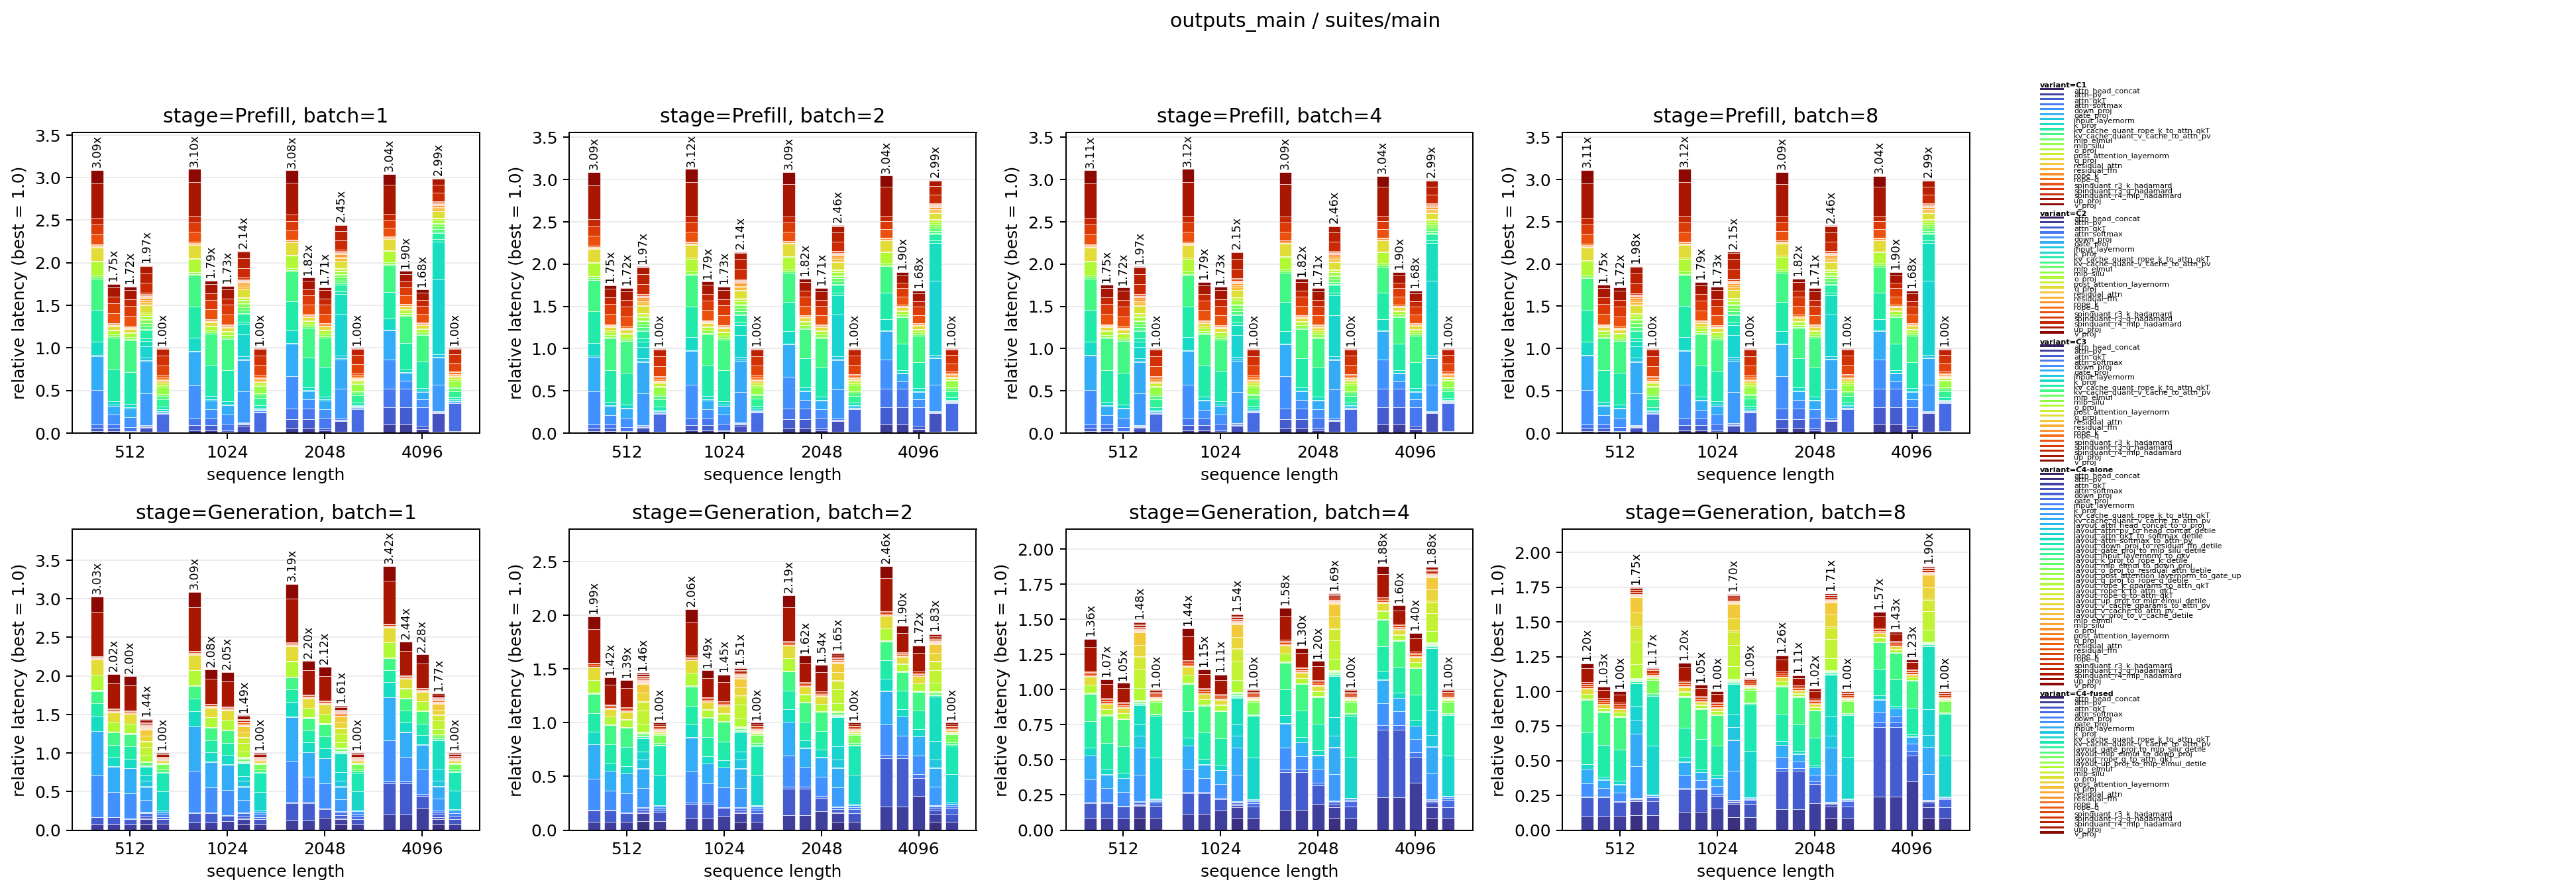

,metric,stage,seq_len,batch,variant,total_latency_us,case_count,pass_case_count,estimated_case_count,missing_case_count,...,estimate_basis,estimate_selected_by,estimate_cv_mape,estimate_train_mape,estimate_group,estimate_mode,estimate_distance,estimate_source_case_id,estimate_source_raw_dbs,estimate_train_rows
0,p50_us,generation,512,1,all_fpint_gemm_improve_alone_layout_spinquant,3.518902e+07,43,43,0,0,...,,,,,,,,,,0
1,p50_us,generation,512,1,all_fpint_gemm_improve_fused_layout_spinquant,2.443600e+07,28,28,0,0,...,,,,,,,,,,0
2,p50_us,generation,512,1,all_fpint_gemm_naive_spinquant,4.887698e+07,24,24,0,0,...,,,,,,,,,,0
3,p50_us,generation,512,1,all_sgemm_tcu_spinquant,7.398153e+07,24,24,0,0,...,,,,,,,,,,0
4,p50_us,generation,512,1,attn_sgemm_tcu_fpint_gemm_naive_spinquant,4.943069e+07,24,24,0,0,...,,,,,,,,,,0


In [4]:
main_result = run_suite_plot("main", out_name="main", figure_title="outputs_main / suites/main")
display_plot(main_result)
main_result.plot_data.head()

## outputs_main + suites/main_all

This section uses the larger main_all suite set with the same outputs_main raw DB and interpolation settings.

wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/main_all


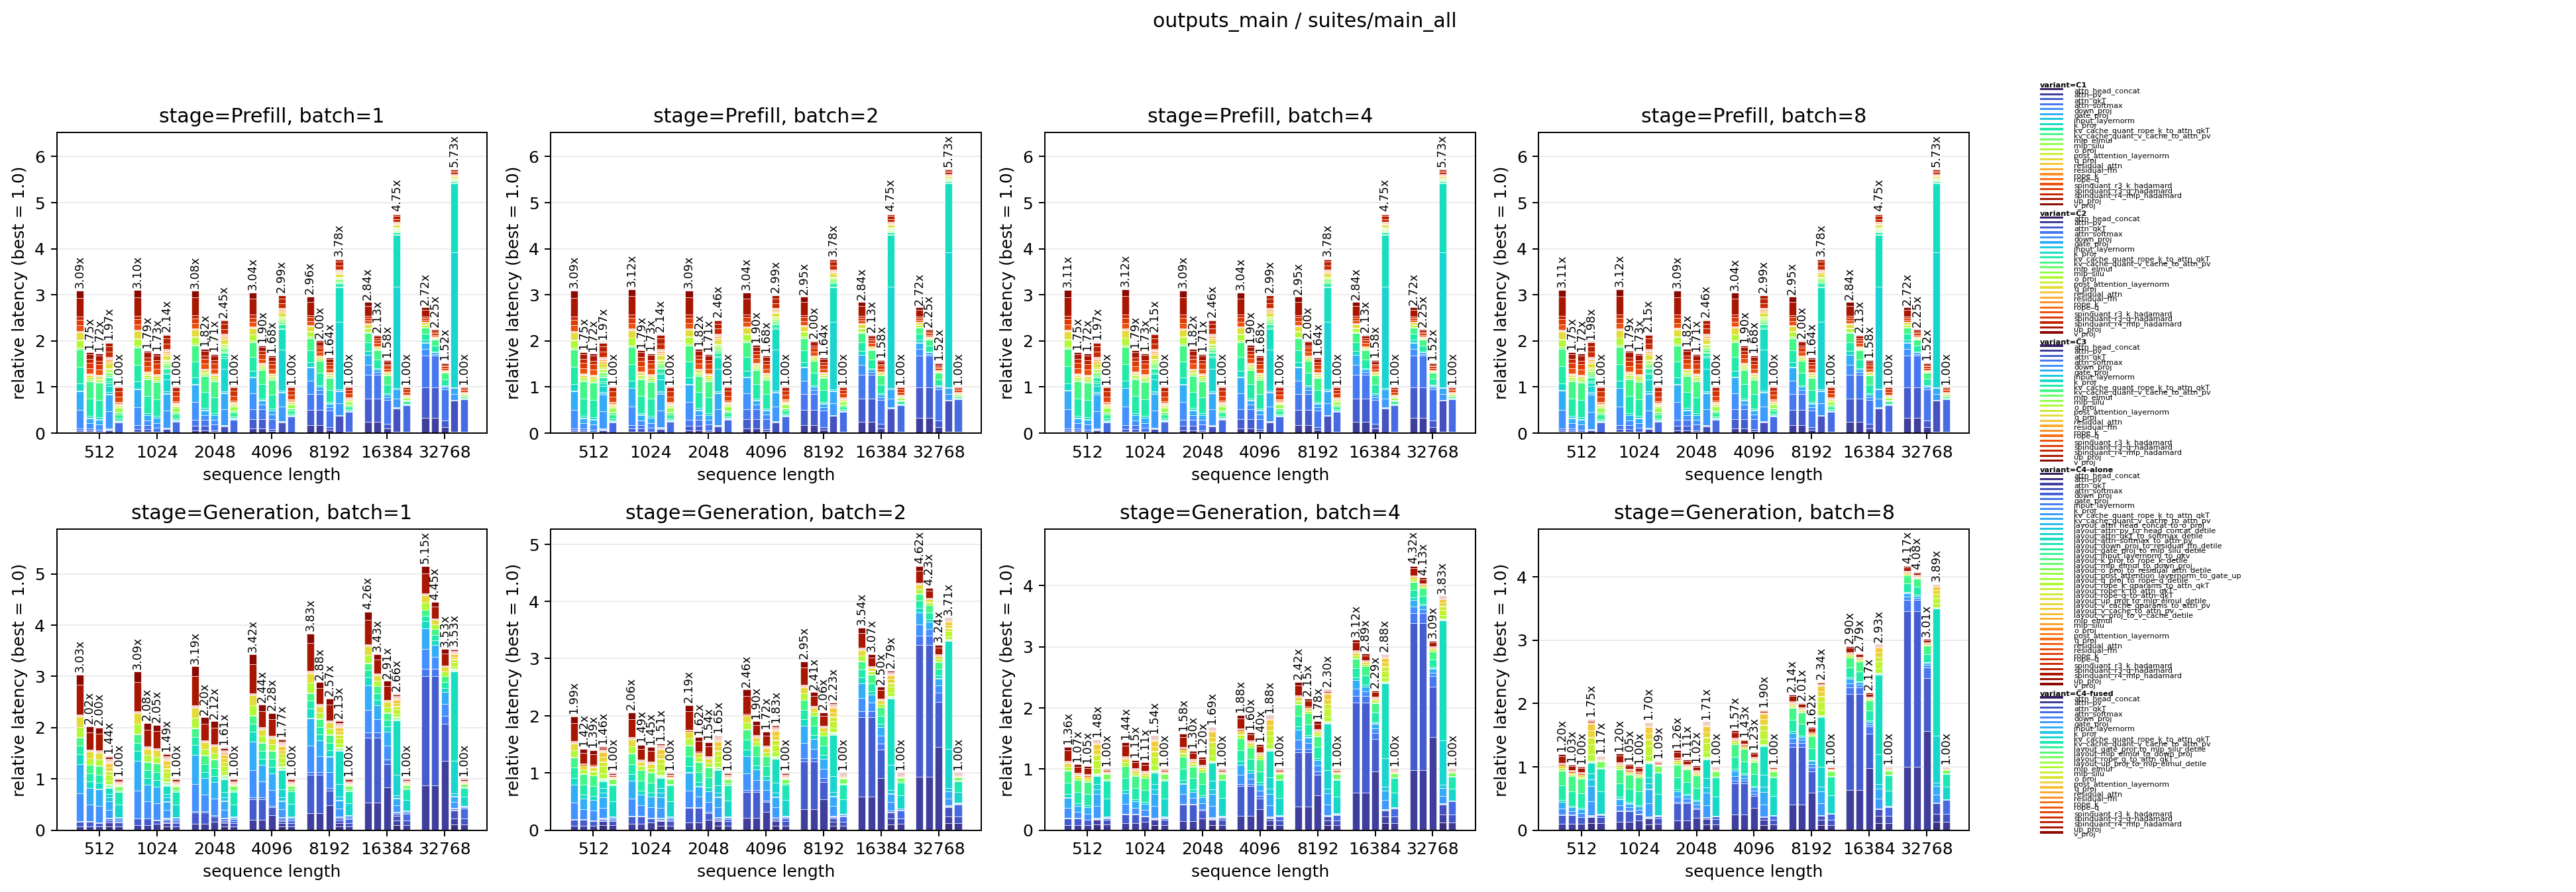

,metric,stage,seq_len,batch,variant,total_latency_us,case_count,pass_case_count,estimated_case_count,missing_case_count,...,estimate_basis,estimate_selected_by,estimate_cv_mape,estimate_train_mape,estimate_group,estimate_mode,estimate_distance,estimate_source_case_id,estimate_source_raw_dbs,estimate_train_rows
0,p50_us,generation,512,1,all_fpint_gemm_improve_alone_layout_spinquant,3.518902e+07,43,43,0,0,...,,,,,,,,,,0
1,p50_us,generation,512,1,all_fpint_gemm_improve_fused_layout_spinquant,2.443600e+07,28,28,0,0,...,,,,,,,,,,0
2,p50_us,generation,512,1,all_fpint_gemm_naive_spinquant,4.887698e+07,24,24,0,0,...,,,,,,,,,,0
3,p50_us,generation,512,1,all_sgemm_tcu_spinquant,7.398153e+07,24,24,0,0,...,,,,,,,,,,0
4,p50_us,generation,512,1,attn_sgemm_tcu_fpint_gemm_naive_spinquant,4.943069e+07,24,24,0,0,...,,,,,,,,,,0


In [5]:
main_all_result = run_suite_plot("main_all", out_name="main_all", figure_title="outputs_main / suites/main_all")
display_plot(main_all_result)
main_all_result.plot_data.head()

## GEMM Only Plots

These cells use the plot API `row_filters` override so only workload cases with `kind == "gemm"` are included in aggregation, stacked bars, and exported CSVs.

In [6]:
GEMM_ONLY_FILTERS = (lambda df: df["kind"].eq("gemm"),)

wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/main_gemm_only


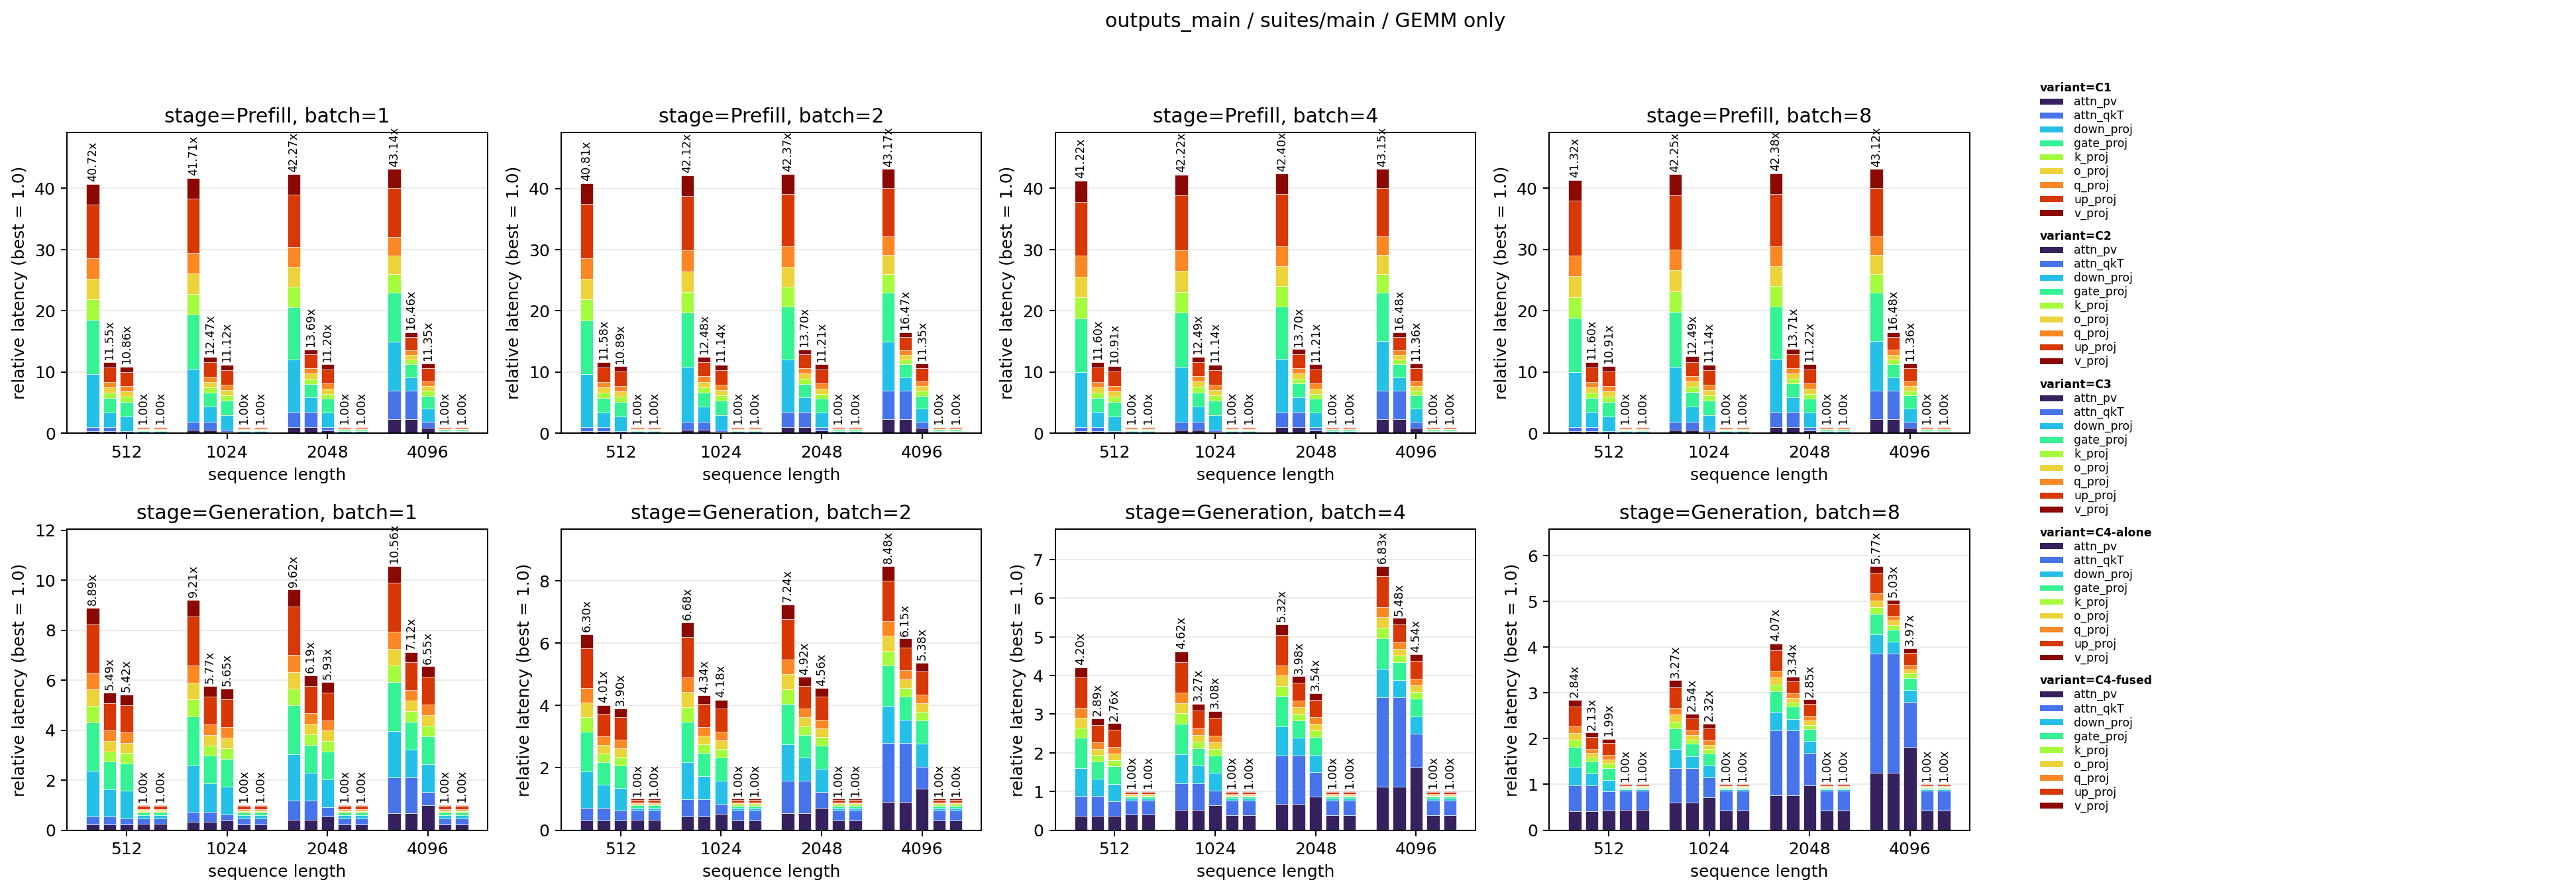

,metric,stage,seq_len,batch,variant,total_latency_us,case_count,pass_case_count,estimated_case_count,missing_case_count,...,estimate_basis,estimate_selected_by,estimate_cv_mape,estimate_train_mape,estimate_group,estimate_mode,estimate_distance,estimate_source_case_id,estimate_source_raw_dbs,estimate_train_rows
0,p50_us,generation,512,1,all_fpint_gemm_improve_alone_layout_spinquant,7.238311e+06,9,9,0,0,...,,,,,,,,,,0
1,p50_us,generation,512,1,all_fpint_gemm_improve_fused_layout_spinquant,7.238311e+06,9,9,0,0,...,,,,,,,,,,0
2,p50_us,generation,512,1,all_fpint_gemm_naive_spinquant,3.921379e+07,9,9,0,0,...,,,,,,,,,,0
3,p50_us,generation,512,1,all_sgemm_tcu_spinquant,6.431833e+07,9,9,0,0,...,,,,,,,,,,0
4,p50_us,generation,512,1,attn_sgemm_tcu_fpint_gemm_naive_spinquant,3.976750e+07,9,9,0,0,...,,,,,,,,,,0


In [7]:
main_gemm_only_result = run_suite_plot(
    "main",
    out_name="main_gemm_only",
    figure_title="outputs_main / suites/main / GEMM only",
    row_filters=GEMM_ONLY_FILTERS,
)
display_plot(main_gemm_only_result)
main_gemm_only_result.plot_data.head()

wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/main_all_gemm_only


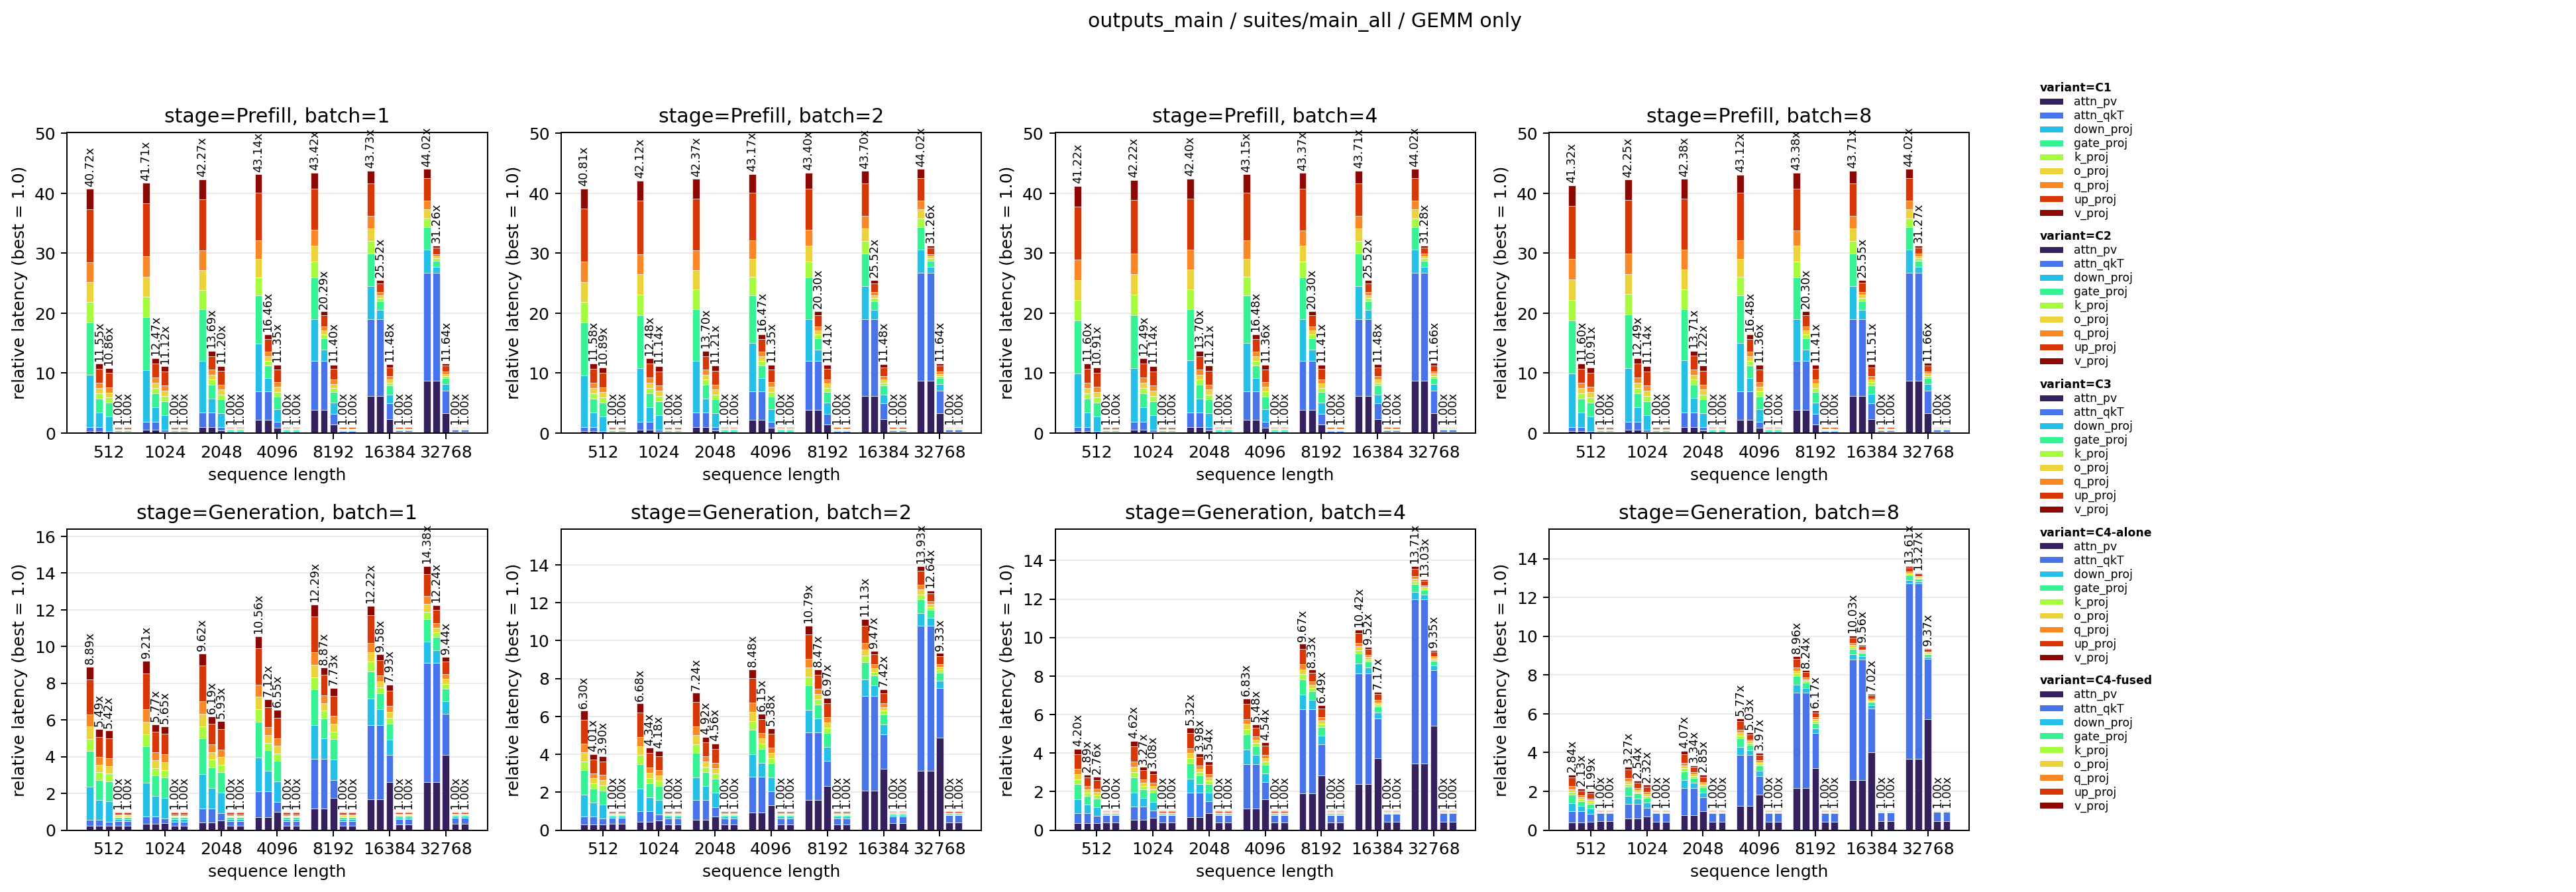

,metric,stage,seq_len,batch,variant,total_latency_us,case_count,pass_case_count,estimated_case_count,missing_case_count,...,estimate_basis,estimate_selected_by,estimate_cv_mape,estimate_train_mape,estimate_group,estimate_mode,estimate_distance,estimate_source_case_id,estimate_source_raw_dbs,estimate_train_rows
0,p50_us,generation,512,1,all_fpint_gemm_improve_alone_layout_spinquant,7.238311e+06,9,9,0,0,...,,,,,,,,,,0
1,p50_us,generation,512,1,all_fpint_gemm_improve_fused_layout_spinquant,7.238311e+06,9,9,0,0,...,,,,,,,,,,0
2,p50_us,generation,512,1,all_fpint_gemm_naive_spinquant,3.921379e+07,9,9,0,0,...,,,,,,,,,,0
3,p50_us,generation,512,1,all_sgemm_tcu_spinquant,6.431833e+07,9,9,0,0,...,,,,,,,,,,0
4,p50_us,generation,512,1,attn_sgemm_tcu_fpint_gemm_naive_spinquant,3.976750e+07,9,9,0,0,...,,,,,,,,,,0


In [8]:
main_all_gemm_only_result = run_suite_plot(
    "main_all",
    out_name="main_all_gemm_only",
    figure_title="outputs_main / suites/main_all / GEMM only",
    row_filters=GEMM_ONLY_FILTERS,
)
display_plot(main_all_gemm_only_result)
main_all_gemm_only_result.plot_data.head()

# Layout Transform Overhead Analysis

Layout fused kernels combine the original vector operation with a layout conversion at the GEMM boundary.

This analysis compares measured `baseline_app` vs `layout_fused_app` rows with the same logical shape. The match key is `(fpga_bin_label, canonical_app, name, canonical_shape_json)`, where `canonical_shape_json` removes layout-only metadata such as `layout_from`, `layout_to`, `producer`, and `consumer`. This catches cases like `rmsnorm` vs `rms_norm_layout_fused`, where CLI args differ (`-batch/-seq/-hidden` vs `-m/-k`) but the logical tensor shape is identical.


In [9]:
import json
import math
import pandas as pd
import matplotlib.pyplot as plt

LAYOUT_OVERHEAD_OUT_DIR = LATENCY_DIR / "outputs_main" / "figures_notebook" / "layout_transform_overhead"
LAYOUT_OVERHEAD_OUT_DIR.mkdir(parents=True, exist_ok=True)

LAYOUT_FUSED_APP_MAP = {
    "eladd_layout_fused": "eladd",
    "elmul_layout_fused": "elmul",
    "head_concat_layout_fused": "head_concat",
    "kv_cache_quant_layout_fused_w4a16": "kv_cache_quant_w4a16",
    "rms_norm_layout_fused": "rmsnorm",
    "rope_layout_fused": "rope",
    "silu_layout_fused": "silu",
    "softmax_layout_fused": "softmax",
}

LAYOUT_SHAPE_DROP_KEYS = {
    "consumer",
    "layout_from",
    "layout_group",
    "layout_to",
    "producer",
    "qparam_layout_to",
    "scale_zp_layout_to",
    "weight_layout_to",
}


def _parse_shape_json(value) -> dict:
    if isinstance(value, dict):
        return dict(value)
    if not isinstance(value, str) or not value.strip():
        return {}
    return json.loads(value)


def _canonical_layout_app(app: str) -> str:
    app = str(app)
    if app in LAYOUT_FUSED_APP_MAP:
        return LAYOUT_FUSED_APP_MAP[app]
    if app.endswith("_layout_fused"):
        return app[: -len("_layout_fused")]
    return app


def _layout_mode(app: str) -> str:
    app = str(app)
    return "layout_fused" if app in LAYOUT_FUSED_APP_MAP or app.endswith("_layout_fused") else "baseline"


def _canonical_shape(shape: dict) -> dict:
    out = {k: v for k, v in shape.items() if k not in LAYOUT_SHAPE_DROP_KEYS}

    # Remove redundant GEMM aliases when the logical vector shape is present.
    if {"batch", "seq", "hidden", "M", "K"}.issubset(out):
        if out.get("M") == out.get("batch") * out.get("seq"):
            out.pop("M", None)
        if out.get("K") == out.get("hidden"):
            out.pop("K", None)

    # Elementwise fused kernels often use M/K args while baseline kernels use size.
    if {"size", "M", "K"}.issubset(out):
        if out.get("size") == out.get("M") * out.get("K"):
            out.pop("M", None)
            out.pop("K", None)

    return dict(sorted(out.items(), key=lambda item: item[0]))


def _canonical_shape_json(shape: dict) -> str:
    return json.dumps(_canonical_shape(shape), sort_keys=True, separators=(",", ":"))


def load_layout_overhead_rows(raw_dbs=RAW_DBS_OUTPUT_MAIN, metric: str = METRIC) -> pd.DataFrame:
    frames = []
    for raw_db in raw_dbs:
        df = pd.read_csv(raw_db)
        df["raw_db"] = str(raw_db)
        frames.append(df)
    raw = pd.concat(frames, ignore_index=True)
    raw = raw[(raw["status"].astype(str) == "pass") & pd.to_numeric(raw[metric], errors="coerce").notna()].copy()
    raw[metric] = pd.to_numeric(raw[metric], errors="coerce")
    raw["layout_mode"] = raw["app"].map(_layout_mode)
    raw["canonical_app"] = raw["app"].map(_canonical_layout_app)
    raw = raw[raw["layout_mode"].isin({"baseline", "layout_fused"})].copy()
    raw["shape_dict"] = raw["shape_json"].map(_parse_shape_json)
    raw["canonical_shape_dict"] = raw["shape_dict"].map(_canonical_shape)
    raw["canonical_shape_json"] = raw["shape_dict"].map(_canonical_shape_json)
    raw["latency_us"] = raw[metric]

    key_cols = ["fpga_bin_label", "canonical_app", "name", "canonical_shape_json"]
    baseline = raw[raw["layout_mode"] == "baseline"].copy()
    fused = raw[raw["layout_mode"] == "layout_fused"].copy()
    baseline = baseline.sort_values("timestamp_utc").drop_duplicates(key_cols, keep="last")
    fused = fused.sort_values("timestamp_utc").drop_duplicates(key_cols, keep="last")

    cols = [
        *key_cols,
        "app",
        "args",
        "shape_json",
        "canonical_shape_dict",
        "latency_us",
        "run_id",
        "case_id",
        "raw_db",
    ]
    pairs = baseline[cols].merge(
        fused[cols],
        on=key_cols,
        how="inner",
        suffixes=("_baseline", "_layout_fused"),
    )
    pairs = pairs.rename(
        columns={
            "app_baseline": "baseline_app",
            "args_baseline": "baseline_args",
            "shape_json_baseline": "baseline_shape_json",
            "latency_us_baseline": "baseline_us",
            "run_id_baseline": "baseline_run_id",
            "case_id_baseline": "baseline_case_id",
            "raw_db_baseline": "baseline_raw_db",
            "app_layout_fused": "layout_fused_app",
            "args_layout_fused": "layout_fused_args",
            "shape_json_layout_fused": "layout_fused_shape_json",
            "latency_us_layout_fused": "layout_fused_us",
            "run_id_layout_fused": "layout_fused_run_id",
            "case_id_layout_fused": "layout_fused_case_id",
            "raw_db_layout_fused": "layout_fused_raw_db",
        }
    )
    if pairs.empty:
        return pairs
    pairs["overhead_us"] = pairs["layout_fused_us"] - pairs["baseline_us"]
    pairs["overhead_pct"] = 100.0 * pairs["overhead_us"] / pairs["baseline_us"]
    pairs["layout_fused_over_baseline"] = pairs["layout_fused_us"] / pairs["baseline_us"]
    pairs["logical_shape"] = pairs["canonical_shape_dict_baseline"].map(lambda x: json.dumps(x, sort_keys=True))
    return pairs.sort_values(["canonical_app", "name", "logical_shape"]).reset_index(drop=True)


def summarize_layout_overhead(overhead: pd.DataFrame) -> pd.DataFrame:
    if overhead.empty:
        return overhead
    return (
        overhead.groupby(["fpga_bin_label", "canonical_app", "baseline_app", "layout_fused_app"], dropna=False)
        .agg(
            pairs=("overhead_us", "size"),
            baseline_us_median=("baseline_us", "median"),
            layout_fused_us_median=("layout_fused_us", "median"),
            overhead_us_median=("overhead_us", "median"),
            overhead_pct_median=("overhead_pct", "median"),
            overhead_pct_mean=("overhead_pct", "mean"),
            overhead_pct_min=("overhead_pct", "min"),
            overhead_pct_max=("overhead_pct", "max"),
            ratio_median=("layout_fused_over_baseline", "median"),
        )
        .reset_index()
        .sort_values(["overhead_pct_median", "canonical_app"], ascending=[False, True])
    )


In [10]:
layout_overhead = load_layout_overhead_rows()
layout_overhead_summary = summarize_layout_overhead(layout_overhead)

layout_overhead_csv = LAYOUT_OVERHEAD_OUT_DIR / "layout_transform_overhead.csv"
layout_overhead_summary_csv = LAYOUT_OVERHEAD_OUT_DIR / "layout_transform_overhead_summary.csv"
layout_overhead.to_csv(layout_overhead_csv, index=False)
layout_overhead_summary.to_csv(layout_overhead_summary_csv, index=False)

print(f"matched baseline/layout_fused pairs: {len(layout_overhead)}")
print(f"wrote {layout_overhead_csv}")
print(f"wrote {layout_overhead_summary_csv}")
display(layout_overhead_summary)


matched baseline/layout_fused pairs: 146
wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/layout_transform_overhead/layout_transform_overhead.csv
wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/layout_transform_overhead/layout_transform_overhead_summary.csv


,fpga_bin_label,canonical_app,baseline_app,layout_fused_app,pairs,baseline_us_median,layout_fused_us_median,overhead_us_median,overhead_pct_median,overhead_pct_mean,overhead_pct_min,overhead_pct_max,ratio_median
1,naive_simd,eladd,eladd,eladd_layout_fused,11,4.392573e+05,1.014651e+06,5.753934e+05,130.992336,98.781811,0.188798,132.133901,2.309923
0,improve_no_tcu_lut_fexp,softmax,softmax,softmax_layout_fused,32,9.817585e+04,2.546324e+05,1.420480e+05,121.237299,152.797559,53.042816,326.857447,2.212373
2,naive_simd,head_concat,head_concat,head_concat_layout_fused,20,1.743428e+06,3.249589e+06,1.494042e+06,84.820841,81.455717,35.148047,92.089906,1.848208
6,naive_simd,softmax,softmax,softmax_layout_fused,30,2.964524e+05,5.263264e+05,2.298740e+05,54.272513,54.768069,31.469615,77.850999,1.542725
5,naive_simd,rope,rope,rope_layout_fused,32,2.425375e+05,3.554088e+05,1.129178e+05,46.168423,45.574789,35.584908,58.965558,1.461684
4,naive_simd,rmsnorm,rmsnorm,rms_norm_layout_fused,11,7.681729e+05,8.426420e+05,7.446911e+04,9.694317,9.763466,-0.660344,39.377453,1.096943
3,naive_simd,kv_cache_quant_w4a16,kv_cache_quant_w4a16,kv_cache_quant_layout_fused_w4a16,10,8.014651e+05,4.915981e+04,-7.511905e+05,-91.907726,-64.106350,-96.201371,56.546725,0.080923


In [11]:
# Detailed per-shape rows. Adjust these filters while debugging.
layout_overhead_view = layout_overhead.copy()
# layout_overhead_view = layout_overhead_view[layout_overhead_view["canonical_app"].eq("softmax")]
# layout_overhead_view = layout_overhead_view[layout_overhead_view["overhead_pct"].abs().gt(20)]

cols = [
    "fpga_bin_label",
    "canonical_app",
    "name",
    "baseline_app",
    "layout_fused_app",
    "baseline_us",
    "layout_fused_us",
    "overhead_us",
    "overhead_pct",
    "layout_fused_over_baseline",
    "logical_shape",
    "baseline_args",
    "layout_fused_args",
]
display(
    layout_overhead_view[cols]
    .sort_values(["canonical_app", "name", "logical_shape"])
    .reset_index(drop=True)
)


,fpga_bin_label,canonical_app,name,baseline_app,layout_fused_app,baseline_us,layout_fused_us,overhead_us,overhead_pct,layout_fused_over_baseline,logical_shape,baseline_args,layout_fused_args
0,naive_simd,eladd,residual_attn,eladd,eladd_layout_fused,1.398603e+07,3.246632e+07,1.848029e+07,132.133901,2.321339,"{""size"": 134217728}",-n 134217728,-m 32768 -k 4096
1,naive_simd,eladd,residual_attn,eladd,eladd_layout_fused,3.740490e+03,5.880560e+03,2.140070e+03,57.213627,1.572136,"{""size"": 16384}",-n 16384,-m 4 -k 4096
2,naive_simd,eladd,residual_attn,eladd,eladd_layout_fused,1.750660e+06,4.052232e+06,2.301572e+06,131.468833,2.314688,"{""size"": 16777216}",-n 16777216,-m 4096 -k 4096
3,naive_simd,eladd,residual_attn,eladd,eladd_layout_fused,2.210644e+05,5.093976e+05,2.883333e+05,130.429568,2.304296,"{""size"": 2097152}",-n 2097152,-m 512 -k 4096
4,naive_simd,eladd,residual_attn,eladd,eladd_layout_fused,5.938867e+03,1.008256e+04,4.143691e+03,69.772416,1.697724,"{""size"": 32768}",-n 32768,-m 8 -k 4096
...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,naive_simd,softmax,attn_softmax,softmax,softmax_layout_fused,1.307669e+05,1.837170e+05,5.295010e+04,40.491987,1.404920,"{""batch"": 8, ""heads"": 32, ""mask"": 0, ""seqk"": 5...",-batch 8 -heads 32 -seqq 1 -seqk 512 -mask 0,-batch 8 -heads 32 -seqq 1 -seqk 512 -mask 0
142,improve_no_tcu_lut_fexp,softmax,attn_softmax,softmax,softmax_layout_fused,3.123730e+04,1.163501e+05,8.511280e+04,272.471696,3.724717,"{""batch"": 8, ""heads"": 32, ""mask"": 0, ""seqk"": 5...",-batch 8 -heads 32 -seqq 1 -seqk 512 -mask 0,-batch 8 -heads 32 -seqq 1 -seqk 512 -mask 0
143,naive_simd,softmax,attn_softmax,softmax,softmax_layout_fused,1.603660e+08,2.303216e+08,6.995563e+07,43.622485,1.436225,"{""batch"": 8, ""heads"": 32, ""mask"": 1, ""seqk"": 1...",-batch 8 -heads 32 -seqq 1024 -seqk 1024 -mask 1,-batch 8 -heads 32 -seqq 1024 -seqk 1024 -mask 1
144,naive_simd,softmax,attn_softmax,softmax,softmax_layout_fused,4.469233e+08,7.050926e+08,2.581693e+08,57.765908,1.577659,"{""batch"": 8, ""heads"": 32, ""mask"": 1, ""seqk"": 2...",-batch 8 -heads 32 -seqq 2048 -seqk 2048 -mask 1,-batch 8 -heads 32 -seqq 2048 -seqk 2048 -mask 1


In [12]:
if not layout_overhead_summary.empty:
    plot_df = layout_overhead_summary.sort_values("overhead_pct_median", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.45 * len(plot_df))))
    labels = plot_df["canonical_app"] + "\n" + plot_df["layout_fused_app"]
    bars = ax.barh(labels, plot_df["overhead_pct_median"], color="#087E8B")
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set_xlabel("median overhead vs baseline (%)")
    ax.set_title("Layout fused overhead by canonical app")
    ax.grid(axis="x", alpha=0.25)
    for bar, value in zip(bars, plot_df["overhead_pct_median"]):
        x = bar.get_width()
        ha = "left" if x >= 0 else "right"
        dx = 1.0 if x >= 0 else -1.0
        ax.text(x + dx, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", ha=ha, fontsize=8)
    fig.tight_layout()
    fig_path = LAYOUT_OVERHEAD_OUT_DIR / "layout_transform_overhead_median_pct.png"
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    print(f"wrote {fig_path}")
    display(fig)


wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/layout_transform_overhead/layout_transform_overhead_median_pct.png


<Figure size 1000x350 with 1 Axes>

### debugging plot data

In [13]:
df_ = main_all_result.stack_data
# df_ = df_[df_["variant"]=="all_fpint_gemm_improve_fused_layout_spinquant"]
df_ = df_[(df_["stage"]=="prefill") & (df_["batch"] == 8) & (df_["seq_len"] == 16384*2)]
print(df_.sort_values(by="total_latency_us").to_csv("data.csv"))

None


In [14]:
df_.columns

Index(['metric', 'stage', 'seq_len', 'batch', 'variant', 'stack_key',
       'total_latency_us', 'case_count', 'pass_case_count',
       'estimated_case_count', 'missing_case_count', 'source_cases',
       'source_suites', 'source_raw_dbs', 'expected_fpga_bin_labels',
       'source_fpga_bin_labels', 'source_latency_scale_rules',
       'source_latency_scales', 'estimate_model', 'estimate_basis',
       'estimate_selected_by', 'estimate_cv_mape', 'estimate_train_mape',
       'estimate_group', 'estimate_mode', 'estimate_distance',
       'estimate_source_case_id', 'estimate_source_raw_dbs',
       'estimate_train_rows'],
      dtype='object')

In [15]:
df_["variant"].unique()

array(['all_fpint_gemm_improve_alone_layout_spinquant',
       'all_fpint_gemm_improve_fused_layout_spinquant',
       'all_fpint_gemm_naive_spinquant', 'all_sgemm_tcu_spinquant',
       'attn_sgemm_tcu_fpint_gemm_naive_spinquant'], dtype=object)

In [16]:
df_[["stack_key", "estimate_cv_mape"]].sort_values(by="estimate_cv_mape").to_csv("estimate_mape.csv")

In [17]:
df_[df_["variant"] == "all_fpint_gemm_improve_fused_layout_spinquant"][["stack_key", "total_latency_us"]].sort_values(by="total_latency_us", ascending=False)

,stack_key,total_latency_us
7911,attn_softmax,1.134435e+12
7932,spinquant_r3_q_hadamard,6.586536e+10
7931,spinquant_r3_k_hadamard,6.586536e+10
7918,layout_gate_proj_to_mlp_silu_detile,4.966423e+10
7921,layout_up_proj_to_mlp_elmul_detile,4.966423e+10
7933,spinquant_r4_mlp_hadamard,4.344695e+10
7919,layout_mlp_elmul_to_down_proj,2.348998e+10
7910,attn_qkT,2.006922e+10
7917,kv_cache_quant_v_cache_to_attn_pv,1.655120e+10
7923,mlp_silu,1.600961e+10


In [18]:
df_[df_["variant"] == "all_fpint_gemm_naive_spinquant"][["stack_key", "total_latency_us"]].sort_values(by="total_latency_us", ascending=False)

,stack_key,total_latency_us
7939,attn_softmax,1.098348e+12
7938,attn_qkT,2.232335e+11
7944,kv_cache_quant_rope_k_to_attn_qkT,2.091643e+11
7945,kv_cache_quant_v_cache_to_attn_pv,2.091008e+11
7937,attn_pv,2.004043e+11
7956,spinquant_r3_q_hadamard,6.586536e+10
7955,spinquant_r3_k_hadamard,6.586536e+10
7940,down_proj,6.344601e+10
7958,up_proj,6.077071e+10
7941,gate_proj,6.077071e+10
